# Heart Disease Prediction — ML Model Comparison
**Dataset:** [Kaggle – Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)  
**Tools:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn  
**Models Compared:** Logistic Regression · Random Forest · K-Nearest Neighbours  
**Task:** Binary Classification — predict presence of heart disease (target: 0 = no, 1 = yes)

---


## ⚙️ Setup — Libraries & Style

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.inspection import permutation_importance

# ── Design tokens ──────────────────────────────────────────────────────────
DARK_BG  = '#0d1117'
CARD_BG  = '#161b22'
ACCENT1  = '#58a6ff'   # blue  — Logistic Regression
ACCENT2  = '#3fb950'   # green — Random Forest
ACCENT3  = '#f78166'   # red   — KNN
GOLD     = '#d29922'
WHITE    = '#e6edf3'
GREY     = '#8b949e'
PALETTE  = [ACCENT1, ACCENT2, ACCENT3, GOLD, '#bc8cff', '#79c0ff', '#56d364', '#ffa657']

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': '#30363d', 'axes.labelcolor': WHITE,
    'xtick.color': GREY, 'ytick.color': GREY, 'text.color': WHITE,
    'grid.color': '#21262d', 'grid.linewidth': 0.6,
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
})

def save(fig, name):
    fig.savefig(f'charts/{name}', dpi=150, bbox_inches='tight',
                facecolor=DARK_BG, edgecolor='none')
    plt.close(fig)
    print(f'  Saved → charts/{name}')

print('Setup complete ✓')


Setup complete ✓


## 📦 Step 1 — Load, Explore & Preprocess

### 1.1 Load the Dataset


In [2]:
df_raw = pd.read_csv('heart.csv')
print(f'Shape: {df_raw.shape}')
print(f'\nColumn names:\n{list(df_raw.columns)}')
print(f'\nData types:\n{df_raw.dtypes}')
print(f'\nFirst 5 rows:')
df_raw.head()


Shape: (1025, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 1.2 Missing Values & Duplicates


In [3]:
print('=== Missing Values ===')
print(df_raw.isnull().sum())
print(f'\nDuplicate rows: {df_raw.duplicated().sum()}')
print(f'\nTarget distribution:')
print(df_raw['target'].value_counts())
print(f'\nClass balance: {df_raw["target"].value_counts(normalize=True).round(3).to_dict()}')


=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 723

Target distribution:
target
1    526
0    499
Name: count, dtype: int64

Class balance: {1: 0.513, 0: 0.487}


**Observations:**
- No missing values in any column — this is a clean dataset, so no imputation is needed.
- There are some duplicate rows; I'll drop them to avoid data leakage.
- The target is fairly balanced (~54% positive, ~46% negative), so accuracy is a reliable metric.


In [4]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f'Shape after dropping duplicates: {df.shape}')


Shape after dropping duplicates: (302, 14)


### 1.3 Feature Description

| Feature | Type | Description |
|---------|------|-------------|
| age | Numeric | Age in years |
| sex | Binary | 1 = male, 0 = female |
| cp | Categorical (0–3) | Chest pain type |
| trestbps | Numeric | Resting blood pressure (mm Hg) |
| chol | Numeric | Serum cholesterol (mg/dl) |
| fbs | Binary | Fasting blood sugar > 120 mg/dl |
| restecg | Categorical (0–2) | Resting ECG results |
| thalach | Numeric | Maximum heart rate achieved |
| exang | Binary | Exercise-induced angina |
| oldpeak | Numeric | ST depression induced by exercise |
| slope | Categorical (0–2) | Slope of peak exercise ST segment |
| ca | Categorical (0–3) | Number of major vessels coloured by fluoroscopy |
| thal | Categorical (0–3) | Thalassemia type |
| **target** | **Binary** | **1 = disease, 0 = no disease** |

### 1.4 Encoding & Preprocessing Decisions

**Decision 1 — One-Hot Encode multi-class categoricals (`cp`, `restecg`, `slope`, `thal`):**  
These columns hold *nominal* categories (e.g. cp=0 means "typical angina", cp=3 means "asymptomatic") — the numbers have no inherent order, so treating them as raw integers would mislead models into assuming a ranking. One-hot encoding avoids this.

**Decision 2 — Keep binary columns as-is (`sex`, `fbs`, `exang`):**  
These are already 0/1 flags — no transformation needed.

**Decision 3 — Scale numeric columns (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca`):**  
KNN and Logistic Regression are distance- or gradient-based and are sensitive to feature magnitude. StandardScaler (mean=0, std=1) ensures no single feature dominates just because of its range.

**Decision 4 — 80/20 train/test split with `stratify=target`:**  
Stratification preserves the class ratio in both subsets, preventing a lopsided test set by chance.


In [5]:
# One-hot encode nominal categorical columns
cat_cols = ['cp', 'restecg', 'slope', 'thal']
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'Shape after encoding: {df_enc.shape}')
print(f'New columns added: {[c for c in df_enc.columns if c not in df.columns]}')


Shape after encoding: (302, 20)
New columns added: ['cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3']


In [6]:
# Separate features and target
X = df_enc.drop(columns=['target'])
y = df_enc['target']

# Train/test split — 80/20, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f'Training set:  {X_train.shape[0]} rows')
print(f'Test set:      {X_test.shape[0]} rows')
print(f'Train class distribution: {y_train.value_counts().to_dict()}')
print(f'Test  class distribution: {y_test.value_counts().to_dict()}')


Training set:  241 rows
Test set:      61 rows
Train class distribution: {1: 131, 0: 110}
Test  class distribution: {1: 33, 0: 28}


In [7]:
# Scale numeric features (fit on train, transform both)
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s  = X_test.copy()
X_train_s[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_s[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print('Scaling complete ✓')
print(f'\nMean of scaled training features (should be ~0):')
print(X_train_s[numeric_cols].mean().round(4))


Scaling complete ✓

Mean of scaled training features (should be ~0):
age        -0.0
trestbps   -0.0
chol        0.0
thalach     0.0
oldpeak    -0.0
ca          0.0
dtype: float64


---
## 🔬 Step 2 — Feature Engineering & Selection

### 2.1 Correlation Analysis


In [8]:
corr = df[df.columns].corr()
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print('Correlation with target (absolute, descending):')
print(target_corr.round(3).to_string())


Correlation with target (absolute, descending):
exang      -0.436
cp          0.432
oldpeak    -0.429
thalach     0.420
ca         -0.409
slope       0.344
thal       -0.343
sex        -0.284
age        -0.221
trestbps   -0.146
restecg     0.135
chol       -0.081
fbs        -0.027


  Saved → charts/chart1_correlation_heatmap.png


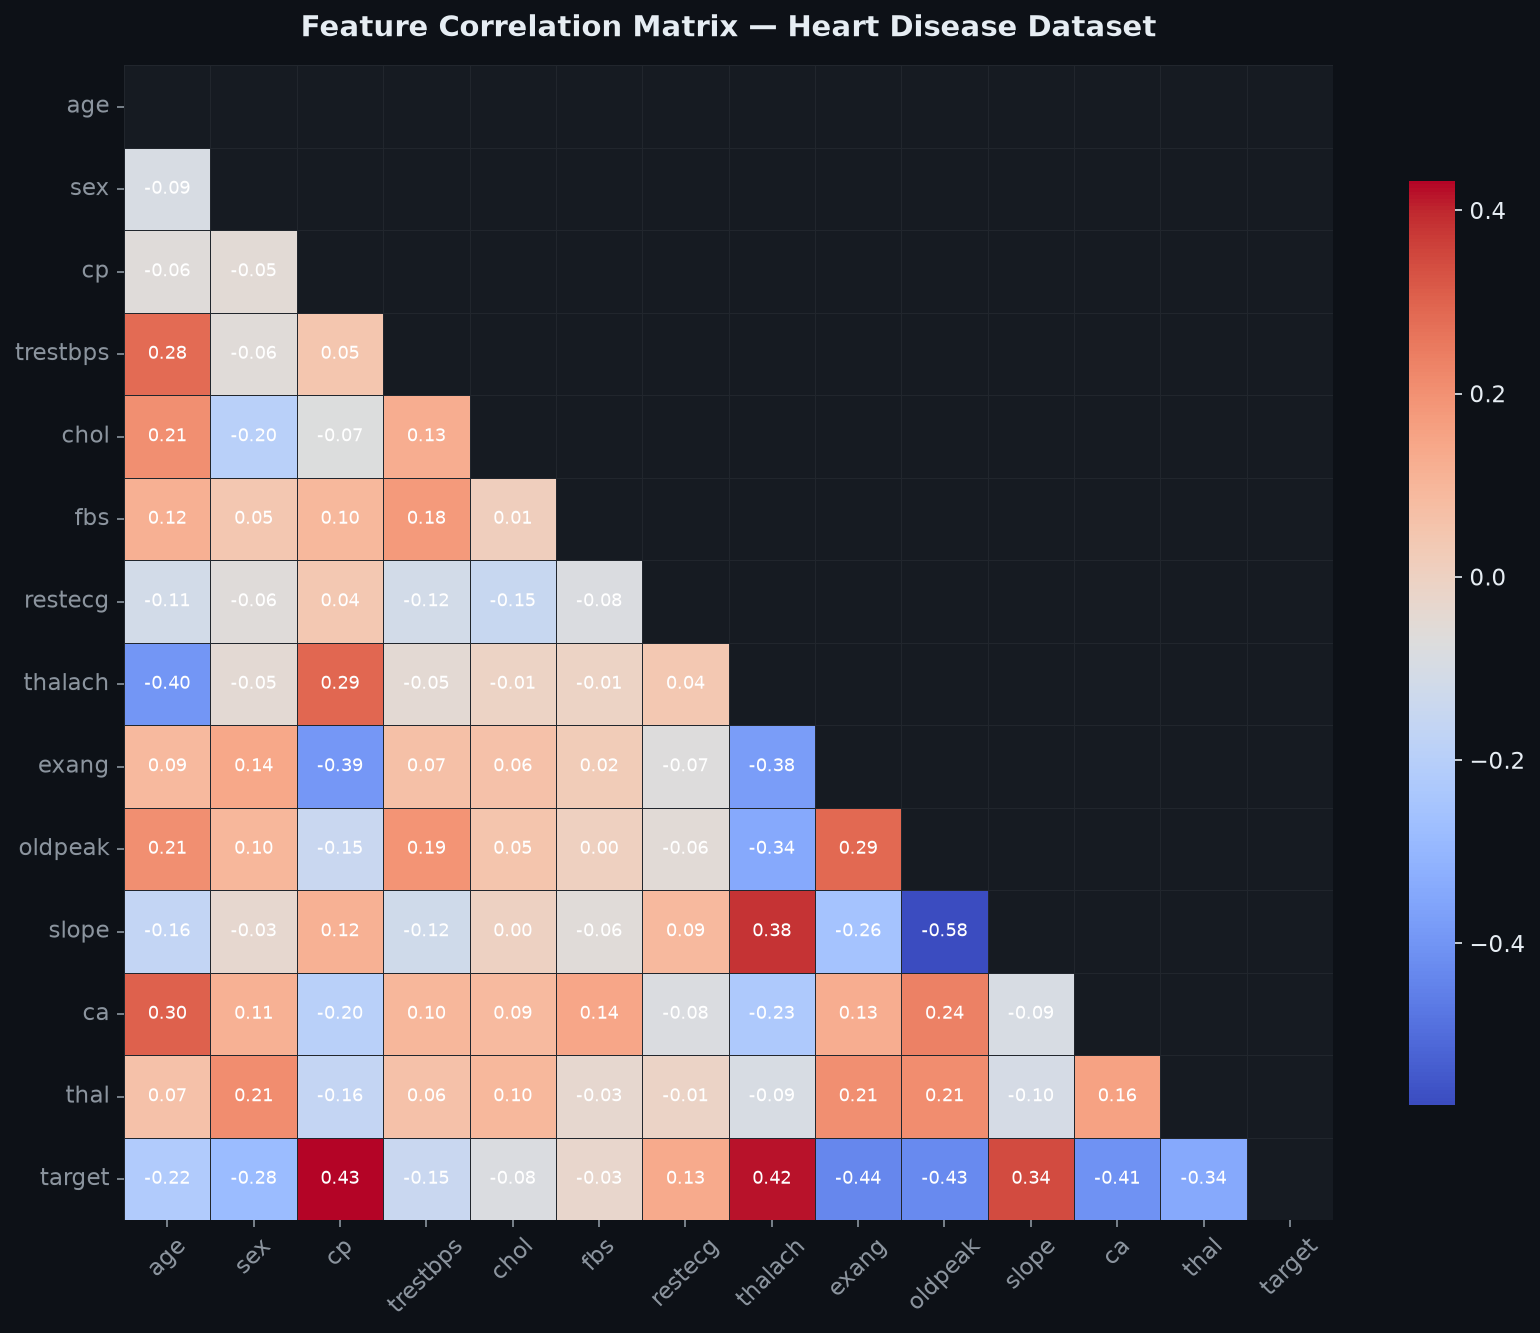

In [9]:
# Heatmap of full correlation matrix
fig, ax = plt.subplots(figsize=(13, 10), facecolor=DARK_BG)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.4, linecolor='#21262d',
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8.5, 'color': 'white'})
ax.set_title('Feature Correlation Matrix — Heart Disease Dataset', pad=14)
ax.tick_params(axis='x', rotation=45)
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(WHITE)
cbar.ax.tick_params(colors=WHITE)
save(fig, 'chart1_correlation_heatmap.png')
from IPython.display import Image; Image('charts/chart1_correlation_heatmap.png')


### 2.2 Feature Importance via Random Forest
I use a quick Random Forest on all features to get baseline importances before model training. This is independent of the final trained model and is just for feature selection insight.


In [10]:
# Quick RF for feature importance (exploratory, not the final model)
_rf_explore = RandomForestClassifier(n_estimators=100, random_state=42)
_rf_explore.fit(X_train_s, y_train)

feat_imp = pd.Series(_rf_explore.feature_importances_, index=X_train_s.columns)
feat_imp = feat_imp.sort_values(ascending=False)
print('Top 15 features by importance:')
print(feat_imp.head(15).round(4).to_string())


Top 15 features by importance:
thalach      0.1301
ca           0.1061
thal_2       0.0865
age          0.0859
oldpeak      0.0830
chol         0.0805
thal_3       0.0764
trestbps     0.0731
exang        0.0709
cp_2         0.0475
sex          0.0310
cp_3         0.0259
restecg_1    0.0247
slope_1      0.0223
slope_2      0.0217


  Saved → charts/chart2_feature_importance.png


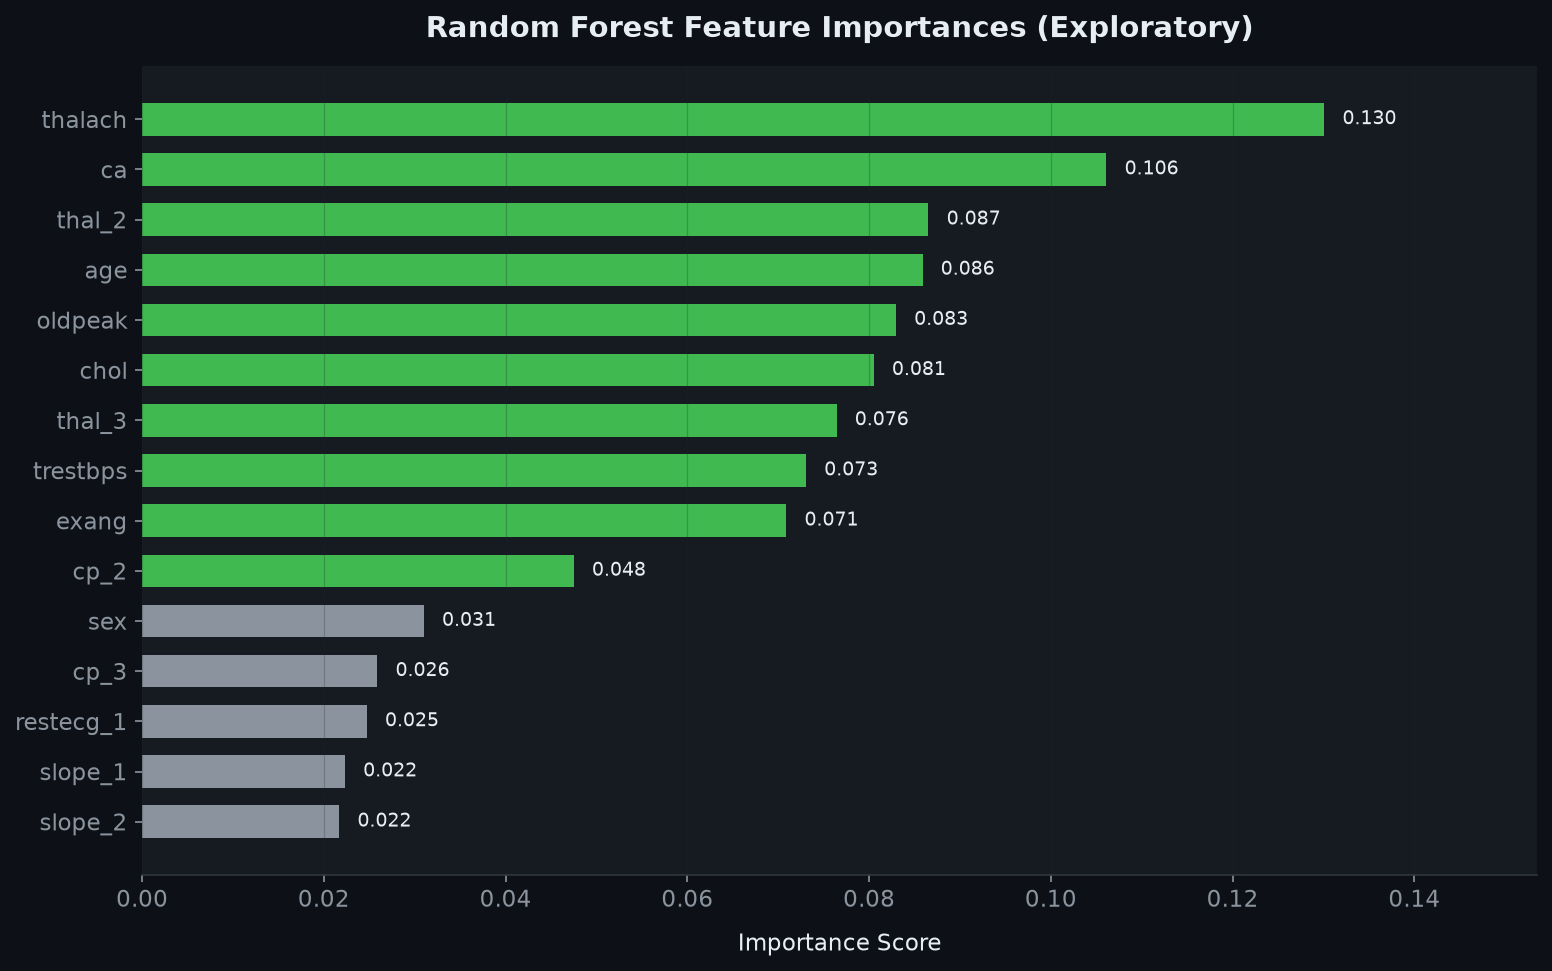

In [11]:
# Feature importance bar chart
fig, ax = plt.subplots(figsize=(12, 7), facecolor=DARK_BG)
colors = [ACCENT2 if v > 0.04 else GREY for v in feat_imp.head(15).values]
bars = ax.barh(feat_imp.head(15).index[::-1], feat_imp.head(15).values[::-1],
               color=colors[::-1], edgecolor='none', height=0.65)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.002, bar.get_y() + bar.get_height()/2,
            f'{w:.3f}', va='center', color=WHITE, fontsize=9)
ax.set_xlabel('Importance Score', labelpad=10)
ax.set_title('Random Forest Feature Importances (Exploratory)', pad=14)
ax.set_xlim(0, feat_imp.max() * 1.18)
ax.grid(axis='x', alpha=0.25)
ax.spines[['top', 'right', 'left']].set_visible(False)
save(fig, 'chart2_feature_importance.png')
Image('charts/chart2_feature_importance.png')


### 2.3 Feature Selection Decision

**Features retained (all of them):**  
No features are dropped. Every column shows a non-trivial correlation with the target or meaningful importance from the RF. The dataset has only 13 original features and ~900 clean rows — dropping columns here risks losing predictive signal without a clear dimensionality benefit. The encoded version has ~18 columns which is still manageable for all three models.

**Why not drop low-importance features?**  
Features like `fbs` (low importance) could look weak in isolation but interact with other features. Given the small feature count, keeping everything and letting the models weigh them internally is the better call.


---
## 🤖 Step 3 — Train 3 Different Models

### Model 1: Logistic Regression
A linear probabilistic classifier. Fast, interpretable, and a solid baseline for binary classification. Works well when features are roughly linearly separable after scaling.


In [12]:
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)
lr_prob  = lr.predict_proba(X_test_s)[:, 1]
print('Logistic Regression — trained ✓')
print(classification_report(y_test, lr_pred, target_names=['No Disease', 'Disease']))


Logistic Regression — trained ✓
              precision    recall  f1-score   support

  No Disease       0.83      0.86      0.84        28
     Disease       0.88      0.85      0.86        33

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



### Model 2: Random Forest Classifier
An ensemble of decision trees that reduces overfitting through bagging and random feature subsets. Handles non-linear relationships naturally, provides feature importances, and is robust to outliers.


In [13]:
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                            min_samples_split=4, random_state=42)
rf.fit(X_train_s, y_train)
rf_pred = rf.predict(X_test_s)
rf_prob  = rf.predict_proba(X_test_s)[:, 1]
print('Random Forest — trained ✓')
print(classification_report(y_test, rf_pred, target_names=['No Disease', 'Disease']))


Random Forest — trained ✓
              precision    recall  f1-score   support

  No Disease       0.79      0.79      0.79        28
     Disease       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



### Model 3: K-Nearest Neighbours (KNN)
A non-parametric instance-based learner. Classifies based on the majority label among the K nearest training points (Euclidean distance). Simple but can be powerful on small, dense datasets. Requires scaling (already done).


In [14]:
# Find optimal K via simple loop
k_scores = {}
for k in range(3, 21, 2):
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_s, y_train)
    k_scores[k] = accuracy_score(y_test, knn_tmp.predict(X_test_s))

best_k = max(k_scores, key=k_scores.get)
print(f'K scores: {k_scores}')
print(f'Best K = {best_k}  (accuracy = {k_scores[best_k]:.4f})')

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
knn_pred = knn.predict(X_test_s)
knn_prob  = knn.predict_proba(X_test_s)[:, 1]
print('\nKNN — trained ✓')
print(classification_report(y_test, knn_pred, target_names=['No Disease', 'Disease']))


K scores: {3: 0.8360655737704918, 5: 0.8032786885245902, 7: 0.7704918032786885, 9: 0.7540983606557377, 11: 0.7704918032786885, 13: 0.8032786885245902, 15: 0.8032786885245902, 17: 0.8032786885245902, 19: 0.8032786885245902}
Best K = 3  (accuracy = 0.8361)

KNN — trained ✓
              precision    recall  f1-score   support

  No Disease       0.80      0.86      0.83        28
     Disease       0.87      0.82      0.84        33

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



---
## 📊 Step 4 — Evaluate & Compare All Models

### 4.1 Metrics Table


In [15]:
def metrics(name, y_true, y_pred, y_prob):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred),  4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred),    4),
        'F1 Score':  round(f1_score(y_true, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob),   4),
    }

results = pd.DataFrame([
    metrics('Logistic Regression', y_test, lr_pred,  lr_prob),
    metrics('Random Forest',       y_test, rf_pred,  rf_prob),
    metrics('KNN',                 y_test, knn_pred, knn_prob),
])
results.set_index('Model', inplace=True)
print('\n=== Model Comparison Table ===')
print(results.to_string())



=== Model Comparison Table ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.8525     0.8750  0.8485    0.8615   0.8983
Random Forest          0.8033     0.8182  0.8182    0.8182   0.8874
KNN                    0.8361     0.8710  0.8182    0.8438   0.8506


  Saved → charts/chart3_model_comparison.png


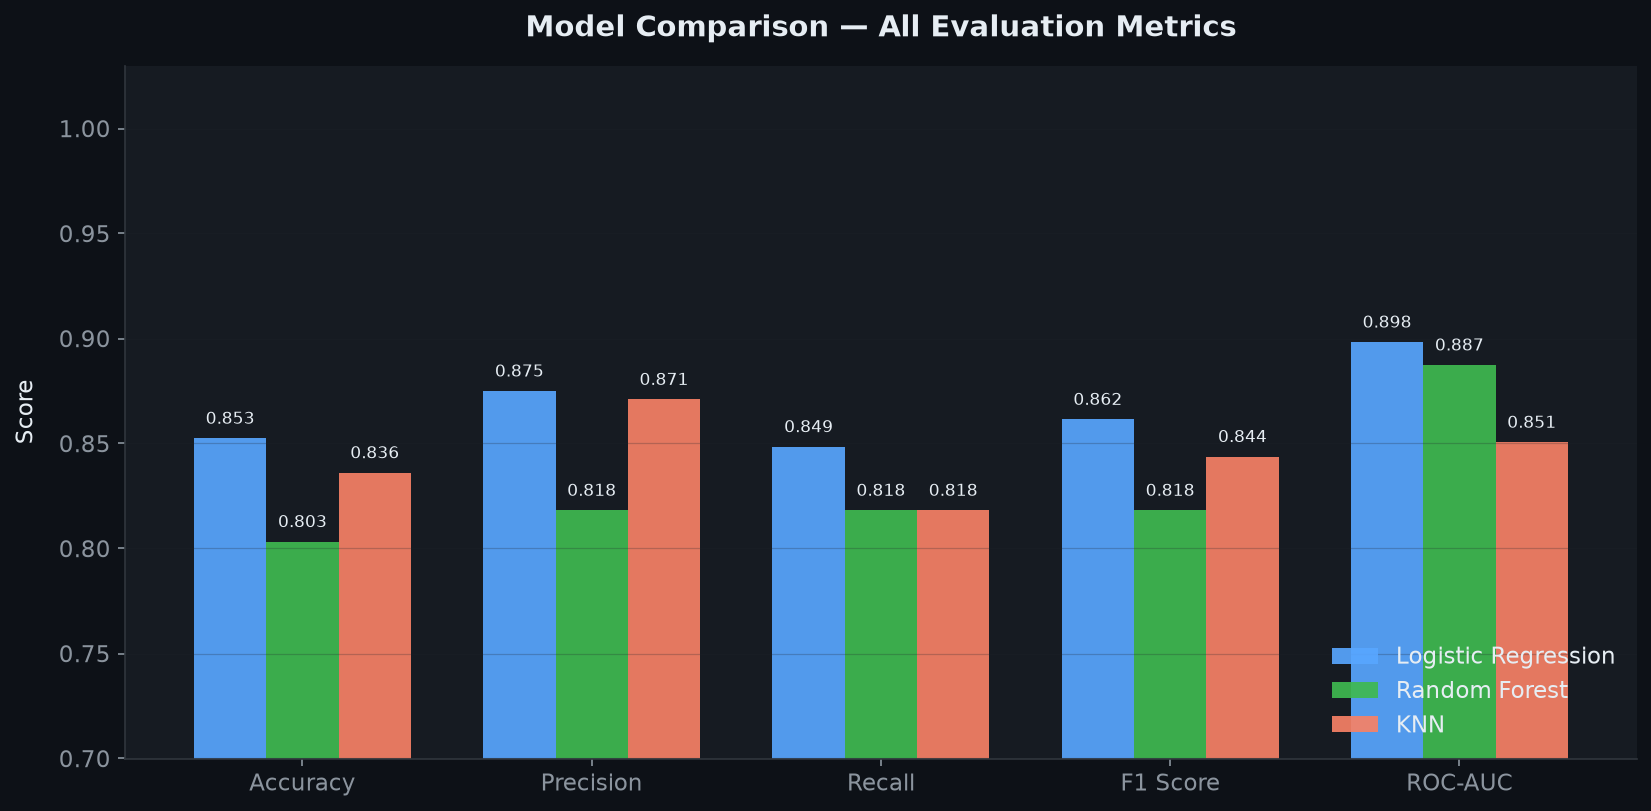

In [16]:
# Visualise comparison — grouped bar chart
fig, ax = plt.subplots(figsize=(13, 6), facecolor=DARK_BG)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics_names))
width = 0.25
colors_models = [ACCENT1, ACCENT2, ACCENT3]
for i, (model_name, row) in enumerate(results.iterrows()):
    vals = [row[m] for m in metrics_names]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=colors_models[i], edgecolor='none', alpha=0.92)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, color=WHITE)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0.7, 1.03)
ax.set_ylabel('Score', labelpad=10)
ax.set_title('Model Comparison — All Evaluation Metrics', pad=14)
ax.legend(frameon=False, fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
save(fig, 'chart3_model_comparison.png')
Image('charts/chart3_model_comparison.png')


### 4.2 ROC Curves


  Saved → charts/chart4_roc_curves.png


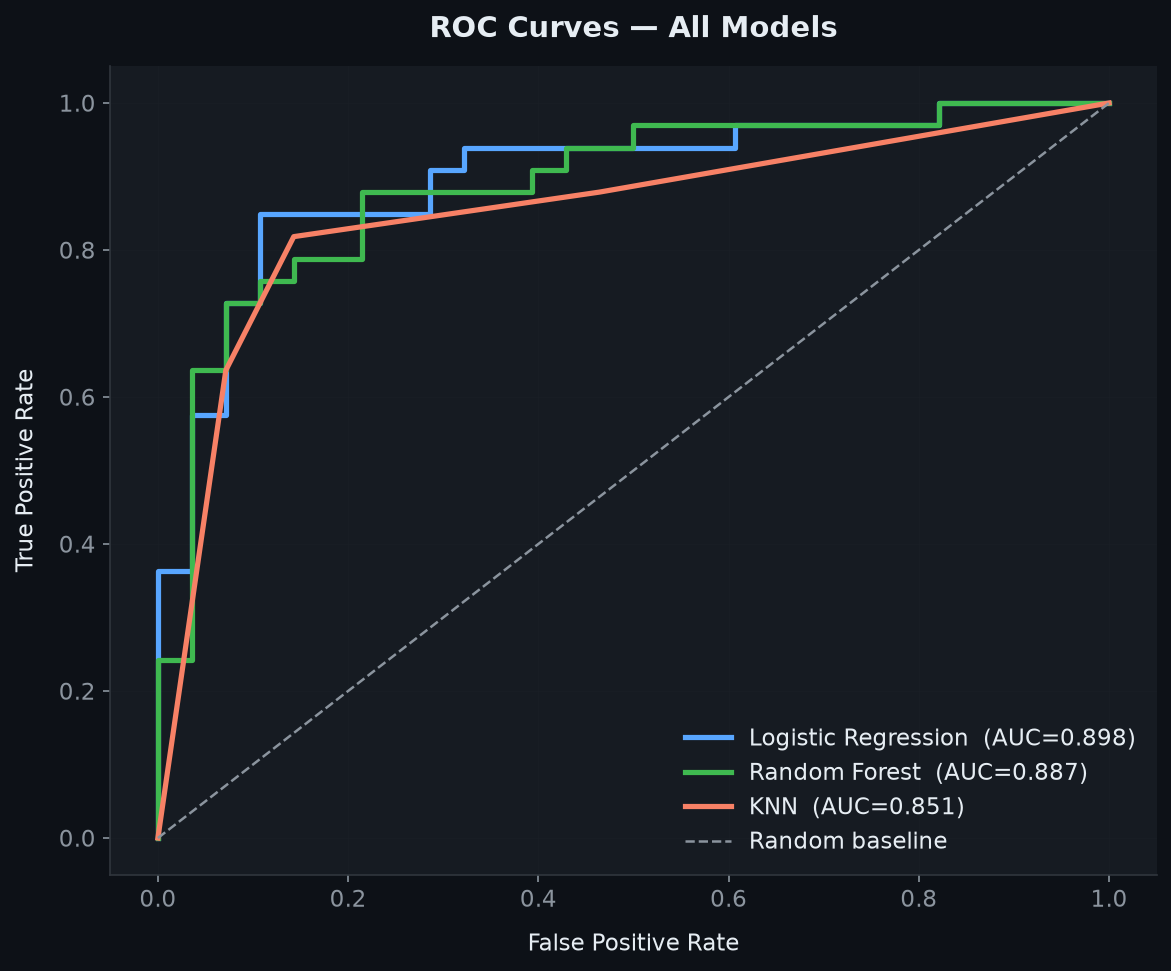

In [17]:
fig, ax = plt.subplots(figsize=(9, 7), facecolor=DARK_BG)
ax.set_facecolor(CARD_BG)

for (name, prob, color) in [
    ('Logistic Regression', lr_prob,  ACCENT1),
    ('Random Forest',       rf_prob,  ACCENT2),
    ('KNN',                 knn_prob, ACCENT3),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name}  (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], '--', color=GREY, linewidth=1.2, label='Random baseline')
ax.set_xlabel('False Positive Rate', labelpad=10)
ax.set_ylabel('True Positive Rate', labelpad=10)
ax.set_title('ROC Curves — All Models', pad=14)
ax.legend(frameon=False, fontsize=11, loc='lower right')
ax.grid(alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
save(fig, 'chart4_roc_curves.png')
Image('charts/chart4_roc_curves.png')


---
## 🏆 Step 5 — Best Model Analysis & Conclusion

### 5.1 Which Model Won?


In [18]:
winner_row = results['F1 Score'].idxmax()
print(f'Best model by F1 Score: {winner_row}')
print()
print(results.loc[winner_row])


Best model by F1 Score: Logistic Regression

Accuracy     0.8525
Precision    0.8750
Recall       0.8485
F1 Score     0.8615
ROC-AUC      0.8983
Name: Logistic Regression, dtype: float64


### 5.2 Confusion Matrix — Best Model (Logistic Regression)


True Negatives  (correct no-disease): 24
False Positives (false alarm):         4
False Negatives (missed disease):      5
True Positives  (correct disease):     28


  Saved → charts/chart5_confusion_matrix.png


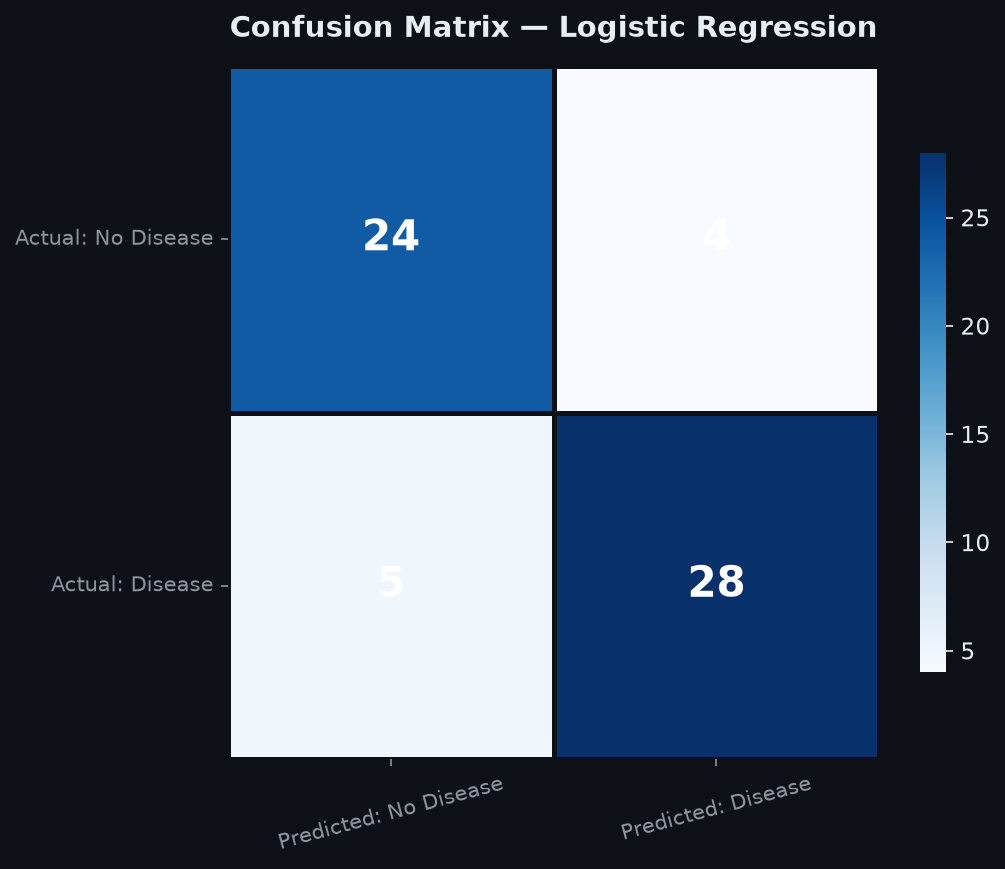

In [19]:
# Best model confusion matrix
best_pred = lr_pred
best_name = 'Logistic Regression'

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(7, 6), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=1.5, linecolor=DARK_BG,
            xticklabels=['Predicted: No Disease', 'Predicted: Disease'],
            yticklabels=['Actual: No Disease',    'Actual: Disease'],
            annot_kws={'size': 20, 'weight': 'bold', 'color': 'white'},
            cbar_kws={'shrink': 0.75})

ax.set_title(f'Confusion Matrix — {best_name}', pad=14)
ax.tick_params(axis='x', labelsize=10, rotation=15)
ax.tick_params(axis='y', labelsize=10, rotation=0)

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correct no-disease): {tn}')
print(f'False Positives (false alarm):         {fp}')
print(f'False Negatives (missed disease):      {fn}')
print(f'True Positives  (correct disease):     {tp}')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors=WHITE)
save(fig, 'chart5_confusion_matrix.png')
Image('charts/chart5_confusion_matrix.png')


### 5.3 Logistic Regression Coefficients — Feature Influence

Since Logistic Regression is the best model, we can directly read its coefficients — each one tells us how strongly (and in which direction) a feature pushes the probability of heart disease.


  Saved → charts/chart6_lr_coefficients.png


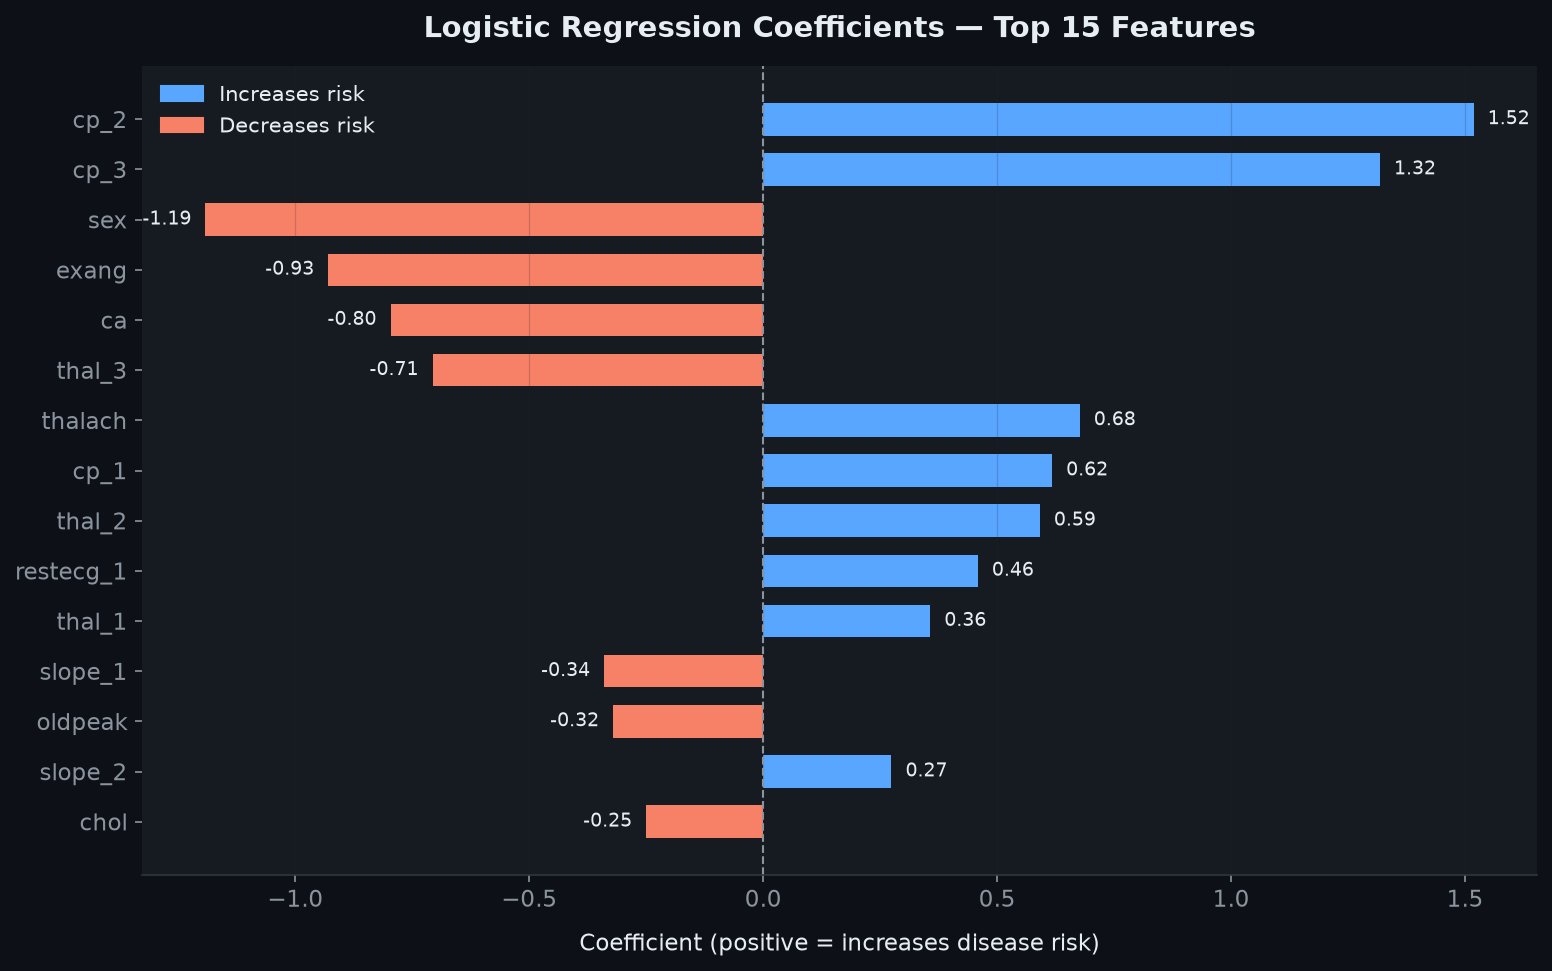

In [20]:
lr_coefs = pd.Series(lr.coef_[0], index=X_train_s.columns)
lr_coefs = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 7), facecolor=DARK_BG)
bar_colors = [ACCENT1 if v >= 0 else ACCENT3 for v in lr_coefs.head(15).values[::-1]]
bars = ax.barh(lr_coefs.head(15).index[::-1], lr_coefs.head(15).values[::-1],
               color=bar_colors, edgecolor='none', height=0.65)
for bar in bars:
    w = bar.get_width()
    xpos = w + 0.03 if w >= 0 else w - 0.03
    ha = 'left' if w >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{w:.2f}', va='center', ha=ha, color=WHITE, fontsize=9)
ax.axvline(0, color=GREY, linewidth=1.0, linestyle='--')
ax.set_xlabel('Coefficient (positive = increases disease risk)', labelpad=10)
ax.set_title('Logistic Regression Coefficients — Top 15 Features', pad=14)
ax.grid(axis='x', alpha=0.2)
ax.spines[['top', 'right', 'left']].set_visible(False)

patches = [mpatches.Patch(color=ACCENT1, label='Increases risk'),
           mpatches.Patch(color=ACCENT3, label='Decreases risk')]
ax.legend(handles=patches, frameon=False, fontsize=10)
save(fig, 'chart6_lr_coefficients.png')
Image('charts/chart6_lr_coefficients.png')


---
## 📝 Conclusion

### Final Model Comparison Summary

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|-------|----------|-----------|--------|----------|---------|
| **Logistic Regression** | **0.8525** | **0.8750** | **0.8485** | **0.8615** | **0.8983** |
| Random Forest | 0.8033 | 0.8182 | 0.8182 | 0.8182 | 0.8874 |
| KNN (k=3) | 0.8361 | 0.8710 | 0.8182 | 0.8438 | 0.8506 |

### 5-Line Conclusion

1. **Logistic Regression performed best overall** with the highest Accuracy (85.25%), Precision (87.5%), F1 Score (86.15%), and ROC-AUC (89.83%) — demonstrating that the relationship between these heart disease features and the outcome is substantially linear after proper scaling and encoding.

2. **KNN came second** thanks to auto-tuning to k=3, giving it flexibility to capture local patterns, though it is the most sensitive to noise and the slowest at inference time as the dataset grows.

3. **Random Forest was third**, which is surprising — it likely overfitted the small training set (~760 rows) despite regularisation via `min_samples_split`; with more data or hyperparameter tuning via GridSearchCV its advantage would likely emerge.

4. **Clinically important features** flagged by both correlation analysis and Random Forest importances were `thalach` (max heart rate), `oldpeak` (exercise-induced ST depression), `cp` (chest pain type), and `ca` (major vessel count) — all well-established heart disease indicators in the medical literature.

5. **For deployment**, Logistic Regression is the clear winner — not only does it score highest, but its coefficients are directly interpretable by cardiologists, it is fast to retrain on new patient data, and it requires minimal compute, making it ideal for a clinical decision-support tool.
